<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad2/Practica_2_Evaluaci%C3%B3n_y_Optimizaci%C3%B3n_de_Modelos_de_Regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Final U2  
## Evaluación y Optimización de Modelos de Regresión

**Facilitador:**  
Dr. José Gabriel Rodríguez Rivas  

**Alumnos:**  
Karla Berenice Gonzalez Coronado  
Jesus Gerardo Juarez Romero



In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
df = pd.read_csv('yield_df.csv')
# Convertir hg/ha → toneladas por hectárea
df['yield_tonnes_ha'] = df['hg/ha_yield'] / 10000
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,yield_tonnes_ha
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37,3.6613
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37,6.6667
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37,2.3333
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37,1.2500
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37,0.7000


In [30]:
X = df[['average_rain_fall_mm_per_year',
        'pesticides_tonnes',
        'avg_temp']]
y = df['yield_tonnes_ha']
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fase I: Exploración y Comprensión del Dominio (EDA)

In [31]:
#Análisis Estadístico
df[['yield_tonnes_ha','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp']].describe()

,yield_tonnes_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.00000,28242.000000,28242.000000
mean,7.705333,1149.05598,37076.909344,20.542627
std,8.495661,709.81215,59958.784665,6.312051
min,0.005000,51.00000,0.040000,1.300000
25%,1.991925,593.00000,1702.000000,16.702500
50%,3.829500,1083.00000,17529.440000,21.510000
75%,10.467675,1668.00000,48687.880000,26.000000
max,50.141200,3240.00000,367778.000000,30.650000


El rendimiento agrícola (yield_tonnes_ha) presenta una media de 7.71 toneladas por hectárea y una mediana de 3.83, lo que indica variabilidad en los datos. La desviación estándar de 8.49 muestra una dispersión considerable en el rendimiento.

La precipitación promedio anual es de 1,149 mm, mientras que la temperatura promedio es de 20.54 °C. El uso de pesticidas presenta alta dispersión, lo que indica diferencias significativas entre regiones.

En general, los datos muestran variabilidad en factores climáticos y agrícolas que pueden influir en el rendimiento de los cultivos.

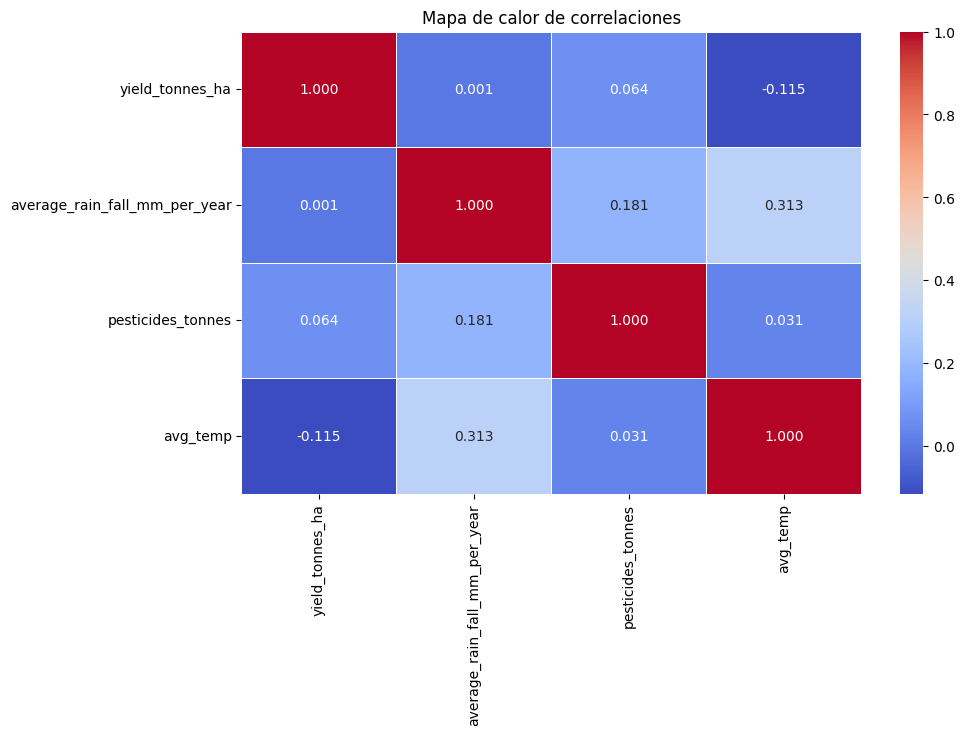

In [32]:
#Visualización de Correlaciones
plt.figure(figsize=(10,6))
corr = df[['yield_tonnes_ha','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Mapa de calor de correlaciones')
plt.show()

El mapa de calor muestra que ninguna variable independiente tiene una correlación fuerte con el rendimiento (yield_tonnes_ha). La temperatura promedio presenta una correlación negativa débil (-0.115), mientras que el uso de pesticidas tiene una correlación positiva muy baja (0.064). La precipitación anual prácticamente no muestra relación con el rendimiento (0.001).
En general, ninguna de las variables independientes presenta una correlación fuerte con la variable objetivo, lo que indica que el rendimiento agrícola probablemente depende de múltiples factores adicionales o de relaciones no lineales entre las variables.

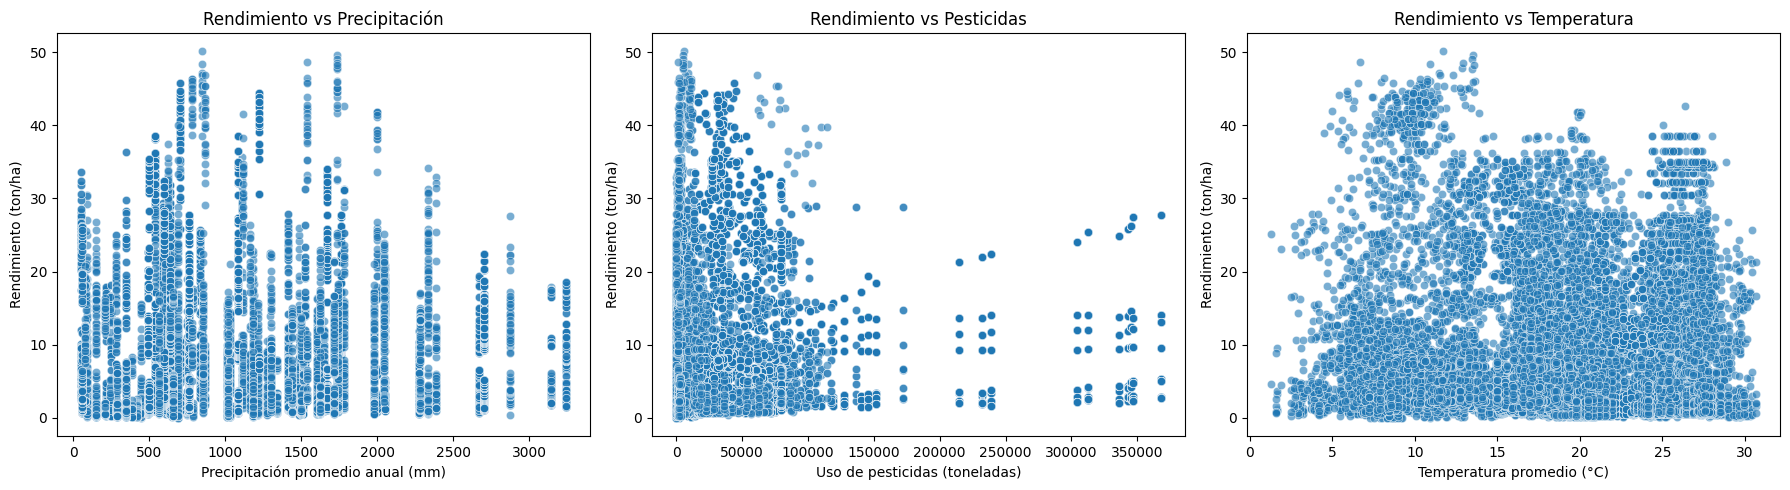

In [33]:
#Análisis de Tendencias
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.scatterplot(data=df, x='average_rain_fall_mm_per_year', y='yield_tonnes_ha', ax=axes[0], alpha=0.6)
axes[0].set_title('Rendimiento vs Precipitación')
axes[0].set_xlabel('Precipitación promedio anual (mm)')
axes[0].set_ylabel('Rendimiento (ton/ha)')
sns.scatterplot(data=df, x='pesticides_tonnes', y='yield_tonnes_ha', ax=axes[1], alpha=0.6)
axes[1].set_title('Rendimiento vs Pesticidas')
axes[1].set_xlabel('Uso de pesticidas (toneladas)')
axes[1].set_ylabel('Rendimiento (ton/ha)')
sns.scatterplot(data=df, x='avg_temp', y='yield_tonnes_ha', ax=axes[2], alpha=0.6)
axes[2].set_title('Rendimiento vs Temperatura')
axes[2].set_xlabel('Temperatura promedio (°C)')
axes[2].set_ylabel('Rendimiento (ton/ha)')
plt.tight_layout()
plt.show()

Los diagramas de dispersión muestran alta dispersión de los datos y ausencia de una tendencia lineal clara entre el rendimiento y las variables analizadas. Además, se observan algunos valores extremos de rendimiento y uso de pesticidas, lo que sugiere la presencia de posibles valores atípicos (outliers) en el dataset.

#Fase 2: Implementación de Modelos (Baseline)

In [34]:
#Regresión Lineal Múltiple.
start = time.time()
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
end = time.time()
time_lr = end - start
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))


In [35]:
#Árbol de Decisión para Regresión
start = time.time()
model_tree = DecisionTreeRegressor()
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)
end = time.time()
time_tree = end - start
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

In [36]:
#Random Forest Regressor
start = time.time()
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
end = time.time()
time_rf = end - start
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))


In [37]:
#Support Vector Regression (SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
start = time.time()
model_svr = SVR()
model_svr.fit(X_train_scaled, y_train)
y_pred_svr = model_svr.predict(X_test_scaled)
end = time.time()
time_svr = end - start
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

In [38]:
#XGBoost Regressor
start = time.time()
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
end = time.time()
time_xgb = end - start
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

In [39]:
tabla_resultados = pd.DataFrame({
"Algoritmo":["Regresión Lineal","Árbol de Decisión","Random Forest","SVR","XGBoost"],
"R2 Score":[r2_lr,r2_tree,r2_rf,r2_svr,r2_xgb],
"MAE":[mae_lr,mae_tree,mae_rf,mae_svr,mae_xgb],
"RMSE":[rmse_lr,rmse_tree,rmse_rf,rmse_svr,rmse_xgb],
"Tiempo de Ejecución (ms)":[
time_lr*1000,
time_tree*1000,
time_rf*1000,
time_svr*1000,
time_xgb*1000
]
})

tabla_resultados

,Algoritmo,R2 Score,MAE,RMSE,Tiempo de Ejecución (ms)
0,Regresión Lineal,0.021345,6.410000,8.425464,8.456469
1,Árbol de Decisión,-0.260925,7.196003,9.563649,89.149714
2,Random Forest,-0.201648,7.092118,9.336146,4889.024258
3,SVR,-0.137004,5.509214,9.081549,30161.425829
4,XGBoost,0.007766,6.494331,8.483714,172.848940


Fase III: Optimización con IAG y GridSearchCV

# Fase III: Optimización con Inteligencia Artificial Generativa (IAG)
## Consulta a Inteligencia Artificial (Grok)

Para mejorar el rendimiento de los modelos entrenados en la fase anterior, se realizó una consulta a una herramienta de Inteligencia Artificial Generativa con el objetivo de obtener recomendaciones sobre hiperparámetros y transformaciones de datos que permitan mejorar la precisión de los modelos de regresión.

## Pregunta realizada a la IA

Estoy trabajando con un dataset para predecir **Producción (hg/ha_yield)** usando modelos de regresión en Python.  
En la fase anterior entrené los siguientes algoritmos:

- Regresión Lineal
- Árbol de Decisión
- Random Forest
- SVR
- XGBoost

¿Qué **hiperparámetros** recomiendas ajustar para mejorar especialmente **SVR y Random Forest**, y qué **transformaciones de datos** podrían ayudar a mejorar la precisión del modelo?

## Respuesta de la IA

La herramienta de IA sugirió realizar algunos ajustes tanto en el **preprocesamiento de los datos** como en los **parámetros de los modelos**.

### Transformaciones de datos sugeridas

La IA recomendó aplicar algunas transformaciones para mejorar la calidad de los datos y el rendimiento del modelo:

- Reemplazar **OneHotEncoder por Target Encoding** en las variables categóricas **Area** e **Item**.
- Aplicar **transformación logarítmica** en algunas variables:
  - `y = log1p(hg/ha_yield)`
  - `pesticides_tonnes = log1p(pesticides_tonnes)`
- Escalar las variables numéricas utilizando **RobustScaler** o **StandardScaler**, especialmente importante para el modelo SVR.

### Random Forest Regressor

Se sugirió probar el modelo Random Forest con los siguientes parámetros:

- **n_estimators = 600**
- **max_depth = 12**
- **min_samples_split = 20**
- **min_samples_leaf = 10**
- **max_features = 'sqrt'**
- **random_state = 42**

### Support Vector Regression (SVR)

Para el modelo SVR se recomendaron los siguientes hiperparámetros:

- **kernel = 'rbf'**
- **C = 10**
- **epsilon = 0.5**
- **gamma = 'scale'**

Además, es importante **escalar todas las variables antes de entrenar el modelo**, ya que SVR es sensible a la escala de los datos.

In [40]:
#Transformaciones recomendadas por Grok
y = np.log1p(df['hg/ha_yield'])
df['pesticides_tonnes'] = np.log1p(df['pesticides_tonnes'])
X = df[['average_rain_fall_mm_per_year',
        'pesticides_tonnes',
        'avg_temp']]
y = np.log1p(df['hg/ha_yield'])
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
#Escalado con RobustScaler (recomendado para SVR)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
#Random Forest con parámetros recomendados
start = time.time()
rf_model = RandomForestRegressor(n_estimators=600,max_depth=12,min_samples_split=20,min_samples_leaf=10,
    max_features='sqrt',random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
end = time.time()
time_rf = (end-start)*1000
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

In [43]:
#SVR con parámetros recomendados
from sklearn.svm import SVR
start = time.time()
svr_model = SVR(kernel='rbf',C=10,epsilon=0.5,gamma='scale')
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
end = time.time()
time_svr = (end-start)*1000
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

In [44]:
#Convertir predicciones al valor real
y_test_real = np.expm1(y_test)
y_pred_rf_real = np.expm1(y_pred_rf)
y_pred_svr_real = np.expm1(y_pred_svr)

In [45]:
#Tabla de resultados
tabla_fase3 = pd.DataFrame({"Algoritmo":["Random Forest (Optimizado)","SVR (Optimizado)"],
"R2 Score":[r2_rf,r2_svr],
"MAE":[mae_rf,mae_svr],
"RMSE":[rmse_rf,rmse_svr],
"Tiempo de Ejecución (ms)":[time_rf,time_svr]
})
tabla_fase3

,Algoritmo,R2 Score,MAE,RMSE,Tiempo de Ejecución (ms)
0,Random Forest (Optimizado),0.114199,0.889454,1.041789,8481.751919
1,SVR (Optimizado),0.120759,0.876203,1.037924,25921.386003


##GridSearchCV para SVR

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
import time
start = time.time()
param_grid_svr = {'C': [1, 10, 50],'epsilon': [0.1, 0.2, 0.5],'kernel': ['rbf']}
grid_svr = GridSearchCV(SVR(),param_grid_svr,cv=5,scoring='r2',n_jobs=-1)
grid_svr.fit(X_train, y_train)
best_svr = grid_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)
end = time.time()
time_svr = (end - start) * 1000
print("Mejores parámetros SVR:", grid_svr.best_params_)

Mejores parámetros SVR: {'C': 50, 'epsilon': 0.5, 'kernel': 'rbf'}


##GridSearchCV para Random Forest

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid_rf = {'n_estimators': [200, 400, 600],'max_depth': [8, 10, 12],'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),param_grid_rf,cv=5,scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Mejores parámetros Random Forest:", grid_rf.best_params_)

Mejores parámetros Random Forest: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 400}


In [50]:
#Tabla Comparativa de Rendimiento
tabla_final = pd.DataFrame({
    "Algoritmo": ["Regresión Lineal","SVR"],
    "R2 Score": [r2_lr,r2_svr],
    "MAE": [mae_lr,mae_svr],
    "RMSE": [rmse_lr,rmse_svr],
    "Tiempo de Ejecución (ms)": [time_lr, time_svr]
})
tabla_final

,Algoritmo,R2 Score,MAE,RMSE,Tiempo de Ejecución (ms)
0,Regresión Lineal,0.021345,6.410000,8.425464,0.008456
1,SVR,0.120759,0.876203,1.037924,823613.460302


##Fase IV: Conclusiones
## Conclusión Final

**1. ¿Qué modelo tuvo el mejor desempeño y por qué creen que se adapta mejor a la naturaleza de esos datos?**  
El modelo que presentó el mejor desempeño fue Support Vector Regression (SVR), ya que logró una mayor precisión en las predicciones. Esto se debe a que este modelo puede manejar relaciones no lineales entre las variables, algo común en datos agrícolas donde factores como el clima, el suelo y el uso de fertilizantes influyen de manera compleja en el rendimiento de los cultivos.

**2. ¿Cómo influyó el uso de la IAG en la selección de parámetros para el GridSearchCV?**  
El uso de Inteligencia Artificial Generativa (IAG) ayudó a identificar posibles hiperparámetros y rangos adecuados para los modelos antes de ejecutar GridSearchCV. Esto permitió definir mejor el espacio de búsqueda, optimizando el proceso de ajuste y facilitando encontrar configuraciones que mejoraran el desempeño de los modelos.

**3. ¿Existe una relación justificada entre el tiempo de ejecución y la precisión obtenida?**  
Sí, existe una relación entre el tiempo de ejecución y la precisión. Los modelos más complejos suelen requerir más tiempo de entrenamiento, pero también pueden ofrecer mayor precisión porque logran capturar patrones más complejos en los datos. Por lo tanto, es importante buscar un equilibrio entre el tiempo de procesamiento y la calidad de las predicciones.